In [21]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from pubmed_loader import PubMedQAData

We plan to use 3 text representation approaches: 
- TF-IDF 
- BioWordVec
- PubMedBERT

## TF-IDF(Axis 1) + Logistic Regression Baseline(Axis 2)


This notebook implements the a simple pipeline: sparse TF-IDF text representation combined with Logistic Regression classification. It serves as the baseline against which BioWordVec and PubMedBERT results will be compared.

**Attention:** This is just an example of how we might do the experiment next, and it doesn't represent the final pipeline. If there is any deficiency in this document, please add it.

### 1. Import and Label definition

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from preprocessing import preprocess_tfidf

from evaluation_plot import evaluate, plot_confusion_matrix, get_error_samples, get_errors_by_type

In [23]:
LABEL_NAMES = {"yes": 0, "no": 1, "maybe": 2}
RANDOM_SEED = 11

def set_all_seeds(seed=RANDOM_SEED):
    random.seed(seed)
    np.random.seed(seed)
    print(f"All seeds set to {seed}")


### 2. Medical Stop Words
Standard English stop word lists (e.g. sklearn's `ENGLISH_STOP_WORDS`) remove words like *"no"*, *"not"*, and *"without"* — which are semantically critical in medical text. For example, *"no significant improvement"* and *"significant improvement"* carry opposite meanings. We manually retain these negation words.

In [24]:
# Set stopwords
MEDICAL_KEEP  = {"no", "not", "without", "never", "neither", "nor"}
med_stopwords = list(ENGLISH_STOP_WORDS - MEDICAL_KEEP)

### 3. Data Loading

In [25]:
data = PubMedQAData("data")

train_texts, train_labels = preprocess_tfidf(data.train_set, use_mesh=True)
dev_texts, dev_labels = preprocess_tfidf(data.dev_set,   use_mesh=True)
test_texts, test_labels = preprocess_tfidf(data.test_set,  use_mesh=True)

print(f"train: {len(train_texts)}")
print(f"dev: {len(dev_texts)}")
print(f"test: {len(test_texts)}")

train: 450
dev: 50
test: 500


Combine train and dev into one large training pool

In [26]:
combined_texts = train_texts + dev_texts
combined_labels = train_labels + dev_labels

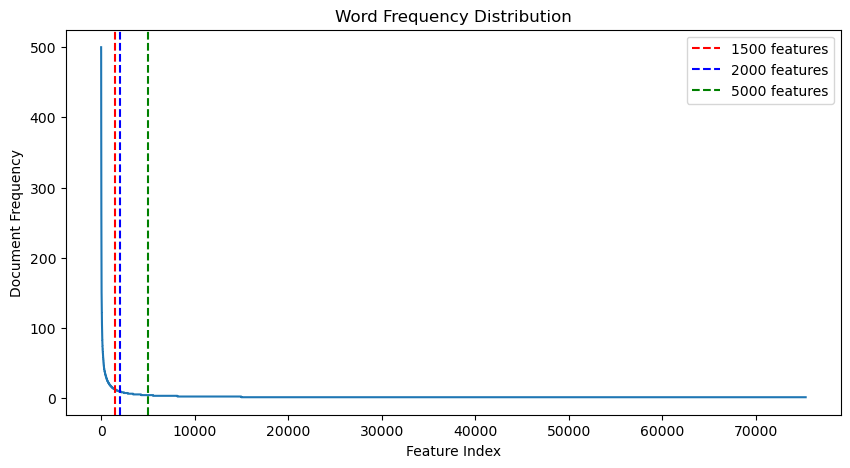

In [27]:
full_vectorizer = TfidfVectorizer(ngram_range=(1, 2))
X_full = full_vectorizer.fit_transform(combined_texts)

df_counts = (X_full > 0).sum(axis=0).tolist()[0]
df_counts.sort(reverse=True)

plt.figure(figsize=(10, 5))
plt.plot(df_counts)
plt.title("Word Frequency Distribution")
plt.xlabel("Feature Index")
plt.ylabel("Document Frequency")
plt.axvline(x=1500, color='r', linestyle='--', label='1500 features')
plt.axvline(x=2000, color='b', linestyle='--', label='2000 features')
plt.axvline(x=5000, color='g', linestyle='--', label='5000 features')
plt.legend()
plt.show()

### 4. TF-IDF Vectorisation

In [28]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),         # unigram + bigram
    stop_words=med_stopwords,   # Set stopwords
    #lowercase=True,            # default
    max_features=1500,
    sublinear_tf=True,
)

# Fit on train, transform all
X_combined = vectorizer.fit_transform(combined_texts)
X_test  = vectorizer.transform(test_texts)
# X_dev   = vectorizer.transform(dev_texts)

In [29]:
print(f"TF-IDF Matrix dimensions: {X_combined.shape}")
print(f"Vocabulary size: {len(vectorizer.vocabulary_)}")

TF-IDF Matrix dimensions: (500, 1500)
Vocabulary size: 1500


### 5. Logistic Regression

Hyperparameter Tuning with Cross-Validation

In [30]:
set_all_seeds()
# We use GridSearchCV to find the best conbination of 'C' and 'solver'
param_grid = {
    #'C': [0.1, 1, 10, 100], # The same list will be used in SVM training
    'C': np.logspace(-1, 2, 10),
    'solver': ['saga', 'lbfgs']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED) # 5 folds cross-validation

grid_search = GridSearchCV(
    LogisticRegression(
        class_weight="balanced", # Handling category imbalance
        max_iter=2000, 
        random_state=RANDOM_SEED
        ),
    param_grid,
    cv=cv,
    scoring='f1_macro', # Optimization target
    n_jobs=4,           # Use 4 CPU cores
)

grid_search.fit(X_combined, combined_labels)

All seeds set to 11


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=11)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': array([ 0.1 ...100. ]), 'solver': ['saga', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",4
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : 

In [31]:
def print_grid_search_summary(grid_search, top_n=5):
    # Extract all experimental results
    results_df = pd.DataFrame(grid_search.cv_results_)
    
    # mean_test_score: f1_macro, std_test_score: the stability of the model
    cols = ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
    summary = results_df[cols].sort_values(by='rank_test_score')
    
    # Print the top N
    print(f"Top {top_n} Hyperparameter Combinations")
    print(summary.head(top_n).to_string(index=False))

In [32]:
print_grid_search_summary(grid_search)

Top 5 Hyperparameter Combinations
                                      params  mean_test_score  std_test_score  rank_test_score
               {'C': 0.1, 'solver': 'lbfgs'}         0.396507        0.026331                1
                {'C': 0.1, 'solver': 'saga'}         0.389360        0.027482                2
{'C': 0.21544346900318834, 'solver': 'saga'}         0.388224        0.026657                3
 {'C': 46.41588833612777, 'solver': 'lbfgs'}         0.385712        0.039951                4
 {'C': 21.54434690031882, 'solver': 'lbfgs'}         0.382592        0.034651                5


Select the best model

In [33]:
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Score (F1): {grid_search.best_score_:.4f}")

best_LR = grid_search.best_estimator_

Best Parameters: {'C': np.float64(0.1), 'solver': 'lbfgs'}
Best CV Score (F1): 0.3965


In [34]:
'''
clf = LogisticRegression(
    class_weight="balanced",    # Handling category imbalance
    max_iter=1000,
    # C=1.0,
    # solver="saga",
)
 
clf.fit(X_train, train_labels)
'''

'\nclf = LogisticRegression(\n    class_weight="balanced",    # Handling category imbalance\n    max_iter=1000,\n    # C=1.0,\n    # solver="saga",\n)\n\nclf.fit(X_train, train_labels)\n'

### 6. Evaluation

In [35]:
y_pred = best_LR.predict(X_test)

In [36]:
# dev_preds  = evaluate(,  dev_labels,  "Dev_set")
evaluate(y_pred, test_labels, "Test_set")


── Test_set ──
Accuracy: 0.4660  Macro-F1: 0.3773
              precision    recall  f1-score   support

         yes       0.59      0.56      0.57       276
          no       0.41      0.41      0.41       169
       maybe       0.14      0.16      0.15        55

    accuracy                           0.47       500
   macro avg       0.38      0.38      0.38       500
weighted avg       0.48      0.47      0.47       500



In [37]:
get_error_samples(data, test_labels, y_pred, n=5)


Error samples (top 5)

PMID: 25475395
Question : Is there a correlation between androgens and sexual desire in women?
True     : yes
Predicted: no

PMID: 24481006
Question : Should cavitation in proximal surfaces be reported in cone beam computed tomography examination?
True     : yes
Predicted: no

PMID: 8165771
Question : Ultrasound in squamous cell carcinoma of the penis; a useful addition to clinical staging?
True     : yes
Predicted: no

PMID: 22680064
Question : Can third trimester ultrasound predict the presentation of the first twin at delivery?
True     : yes
Predicted: no

PMID: 22540518
Question : Is micro-computed tomography reliable to determine the microstructure of the maxillary alveolar bone?
True     : yes
Predicted: maybe


==== Error Analysis ====

True=yes (total=276, correct=154, error=122):
   Predicted no: 88/276 (31.9%)
   Predicted maybe: 34/276 (12.3%)

True=no (total=169, correct=70, error=99):
   Predicted yes: 77/169 (45.6%)
   Predicted maybe: 22/169 (13.0%)

True=maybe (total=55, correct=9, error=46):
   Predicted yes: 32/55 (58.2%)
   Predicted no: 14/55 (25.5%)


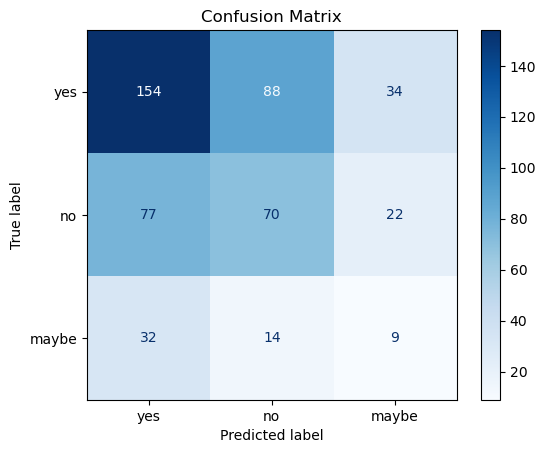

In [38]:
plot_confusion_matrix(test_labels, y_pred)

In [39]:
get_errors_by_type(data, test_labels, y_pred, true_class="maybe", pred_class="yes", n=3)

True=maybe  Predicted=yes  (total 32 errors, showing 3)
  Question: Expression of c-kit protooncogen in hepatitis B virus-induced chronic hepatitis, cirrhosis and hepatocellular carcinoma: has it a diagnostic role?
  Context: ['Paraffin-embedded tissues in Cukurova University Faculty of Medicine Department of Pathology between January 2002 and February 2006 were searched restrospectively to investigate this issue. We performed immunohistochemistry on biopsies of 125 patients with HBV infection, grouped as: mild, moderate and severe hepatitis, cirrhosis and HCC, 25 patients in each of them, using anti c-kit monoclonal antibody. The severity of parenchymal inflammation and of interface hepatitis was semiquantitatively graded on a haematoxylin and eosin stained paraffin sections. Additionally, 50 more HCC, formed on HBV basis, were studied to determine the prevalence of c-kit overexpression.', 'In cirrhotic liver, lower intensity of staining and rarely c-kit positivity were present. The g

In [40]:
get_errors_by_type(data, test_labels, y_pred, true_class="no", pred_class="yes", n=3)

True=no  Predicted=yes  (total 77 errors, showing 3)
  Question: Does strategy training reduce age-related deficits in working memory?
  Context: ['Older adults typically perform worse on measures of working memory (WM) than do young adults; however, age-related differences in WM performance might be reduced if older adults use effective encoding strategies.', 'The purpose of the current experiment was to evaluate WM performance after training individuals to use effective encoding strategies.', 'Participants in the training group (older adults: n = 39; young adults: n = 41) were taught about various verbal encoding strategies and their differential effectiveness and were trained to use interactive imagery and sentence generation on a list-learning task. Participants in the control group (older: n = 37; young: n = 38) completed an equally engaging filler task. All participants completed a pre- and post-training reading span task, which included self-reported strategy use, as well as two